# Workshop: Time Series Forecasting (w. Machine Learning)

## Session 4:  Neural Networks for Time Series Forecasting

In previous sessions, we explored **statistical models** (Session 1) and **machine learning models** (Sessions 2 & 3). Now we'll dive into **neural networks**!

### Covering:
1. **NeuralForecast Library** - deep learning made easy for time series
2. **Popular Neural Models** - NBEATS, NHITS
3. **Automatic Hyperparameter Tuning** - using AutoNBEATS and AutoNHITS
4. **Model Comparison** - evaluating neural network performance

### Why Neural Networks?

**Advantages**:
- ✅ Capture **complex non-linear patterns**
- ✅ Learn **temporal dependencies** automatically
- ✅ Handle **multiple time series** efficiently (global models)
- ✅ **Automatic feature learning** (no manual feature engineering)

**Trade-offs**:
- ⚠️ Require more data and computational resources
- ⚠️ Longer training times
- ⚠️ Less interpretable than simpler models

Let's get started!

## 1. Setup and Imports

In [1]:
%pip install neuralforecast

You should consider upgrading via the 'c:\Users\u0153325\OneDrive - Hogeschool VIVES\Documenten\VIS\Cloud-for-AI\.venv\Scripts\python.exe -m pip install --upgrade pip' command.



     -------------------------------------- 263.2/263.2 KB 8.2 MB/s eta 0:00:00
     ------------------------------------- 832.4/832.4 KB 17.5 MB/s eta 0:00:00
     -------------------------------------- 241.2/241.2 MB 7.4 MB/s eta 0:00:00
     ---------------------------------------- 26.6/26.6 MB 8.3 MB/s eta 0:00:00
     ------------------------------------- 983.2/983.2 KB 15.4 MB/s eta 0:00:00
     ---------------------------------------- 90.0/90.0 KB 5.0 MB/s eta 0:00:00
     ------------------------------------- 436.9/436.9 KB 13.8 MB/s eta 0:00:00
     ---------------------------------------- 71.5/71.5 KB ? eta 0:00:00
     ---------------------------------------- 98.2/98.2 KB 5.9 MB/s eta 0:00:00
     ---------------------------------------- 64.7/64.7 KB 3.4 MB/s eta 0:00:00
     ---------------------------------------- 87.2/87.2 KB 5.1 MB/s eta 0:00:00
     ---------------------------------------- 6.3/6.3 MB 18.3 MB/s eta 0:00:00
     ---------------------------------------- 1

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# NeuralForecast
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS
from neuralforecast.auto import AutoNBEATS, AutoNHITS

# Metrics
from sklearn.metrics import mean_squared_error

# Plotting
plt.style.use("ggplot")
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)


2025-10-20 14:03:53,853	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-10-20 14:03:54,175	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## 2. Load Data and Train/Test Split

We'll use the same M5 food sales dataset from previous sessions.

In [2]:
# Load the data
path = 'C:/Users/u0153325/OneDrive - Hogeschool VIVES/Documenten/VIS/Cloud-for-AI/workshop_ml_2025/data/converted_df.csv'

df = pd.read_csv(path, parse_dates=['date'])

print(f"Dataset shape: {df.shape}")
print(f"Number of stores: {df['unique_id'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nFirst few rows:")
df.head(10)

Dataset shape: (12100, 3)
Number of stores: 10
Date range: 2013-01-01 00:00:00 to 2016-04-24 00:00:00

First few rows:


,unique_id,date,y
0,CA_1,2013-01-01,1888
1,CA_2,2013-01-01,1320
2,CA_3,2013-01-01,2454
3,CA_4,2013-01-01,1031
4,TX_1,2013-01-01,1607
5,TX_2,2013-01-01,2469
6,TX_3,2013-01-01,1773
7,WI_1,2013-01-01,1365
8,WI_2,2013-01-01,1506
9,WI_3,2013-01-01,1415


In [3]:
# Train/Test Split: last 14 days for testing (same as previous sessions)
test_size = 14
max_date = df["date"].max()
split_date = max_date - pd.Timedelta(days=test_size - 1)

df_train = df[df["date"] < split_date].copy()
df_test = df[df["date"] >= split_date].copy()

print(f"Train/Test Split:")
print("=" * 60)
print(f"Training set: {len(df_train):,} observations")
print(f"Test set: {len(df_test):,} observations")
print(f"\nDate ranges:")
print(f"  Train: {df_train['date'].min()} to {df_train['date'].max()}")
print(f"  Test:  {df_test['date'].min()} to {df_test['date'].max()}")
print(f"\nForecast horizon: {test_size} days")

# Store list
stores = df["unique_id"].unique()
print(f"\nStores: {list(stores)}")

Train/Test Split:
Training set: 11,960 observations
Test set: 140 observations

Date ranges:
  Train: 2013-01-01 00:00:00 to 2016-04-10 00:00:00
  Test:  2016-04-11 00:00:00 to 2016-04-24 00:00:00

Forecast horizon: 14 days

Stores: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


## 3. Understanding NeuralForecast Data Format

**NeuralForecast requires:**
- `unique_id`: identifier for each time series
- `ds`: timestamp column (datestamp)
- `y`: target variable

Our data already has `unique_id` and `y`, we just need to rename `date` to `ds`!

In [6]:
# Prepare data for NeuralForecast
df_train_nf = df_train.rename(columns={"date": "ds"})
df_test_nf = df_test.rename(columns={"date": "ds"})

print("Data prepared for NeuralForecast:")
print("=" * 60)
print(df_train_nf.head())
print(f"\nColumns: {list(df_train_nf.columns)}")
print("✅ Format ready: unique_id, ds, y")

Data prepared for NeuralForecast:
  unique_id         ds     y
0      CA_1 2013-01-01  1888
1      CA_2 2013-01-01  1320
2      CA_3 2013-01-01  2454
3      CA_4 2013-01-01  1031
4      TX_1 2013-01-01  1607

Columns: ['unique_id', 'ds', 'y']
✅ Format ready: unique_id, ds, y


## 4. Introduction to Neural Network Models

We'll explore two popular neural network architectures:

### 1. **NBEATS** (Neural Basis Expansion Analysis)
- **Key Idea**: Decomposes forecasts into trend and seasonality components using basis functions
- **Interpretable**: Can visualize trend/seasonal contributions
- **Architecture**: Deep residual blocks with doubly residual stacking
- **Best for**: Interpretable forecasts with clear decomposition
- **Paper**: [NBEATS: Neural basis expansion analysis for interpretable time series forecasting](https://arxiv.org/abs/1905.10437)

### 2. **NHITS** (Neural Hierarchical Interpolation for Time Series)
- **Key Idea**: Multi-rate interpolation across different temporal scales
- **Fast**: More efficient than NBEATS (fewer parameters)
- **Architecture**: Hierarchical stacks with interpolation
- **Best for**: Long-horizon forecasting with speed requirements
- **Paper**: [NHITS: Neural Hierarchical Interpolation for Time Series Forecasting](https://arxiv.org/abs/2201.12886)

Let's start by training simple models with default parameters!

## 5. Train NBEATS with Default Parameters

We'll start with a simple NBEATS model using minimal configuration.

In [9]:
# Train NBEATS with simple parameters
print("Training NBEATS...")

# Initialize model
# h = forecast horizon (14 days)
# input_size = number of historical steps to use (2 * h is a good default)
# max_steps = training iterations (keep low for speed)
models_nbeats = [
    NBEATS(
        h=test_size,
        input_size=2 * test_size,
        max_steps=500,
        
        early_stop_patience_steps=3
    )
]

# Create NeuralForecast object
nf_nbeats = NeuralForecast(models=models_nbeats, freq="D")

# Fit model
nf_nbeats.fit(df=df_train_nf, val_size = 5*14)

# Generate forecasts
forecasts_nbeats = nf_nbeats.predict()

print("\n✅ NBEATS trained and forecasted!")
print(f"Forecast shape: {forecasts_nbeats.shape}")
forecasts_nbeats.head()

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
1.2 K     Non-trainable params
2.5 M     Total params
9.844     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Training NBEATS...
Epoch 499: 100%|██████████| 1/1 [00:00<00:00,  5.65it/s, v_num=10, train_loss_step=189.0, train_loss_epoch=189.0, valid_loss=243.0]

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 499: 100%|██████████| 1/1 [00:00<00:00,  5.50it/s, v_num=10, train_loss_step=189.0, train_loss_epoch=189.0, valid_loss=243.0]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 90.42it/s] 

✅ NBEATS trained and forecasted!
Forecast shape: (140, 3)


,unique_id,ds,NBEATS
0,CA_1,2016-04-11,2833.580078
1,CA_1,2016-04-12,2545.503174
2,CA_1,2016-04-13,2586.410156
3,CA_1,2016-04-14,2628.575439
4,CA_1,2016-04-15,3081.643311


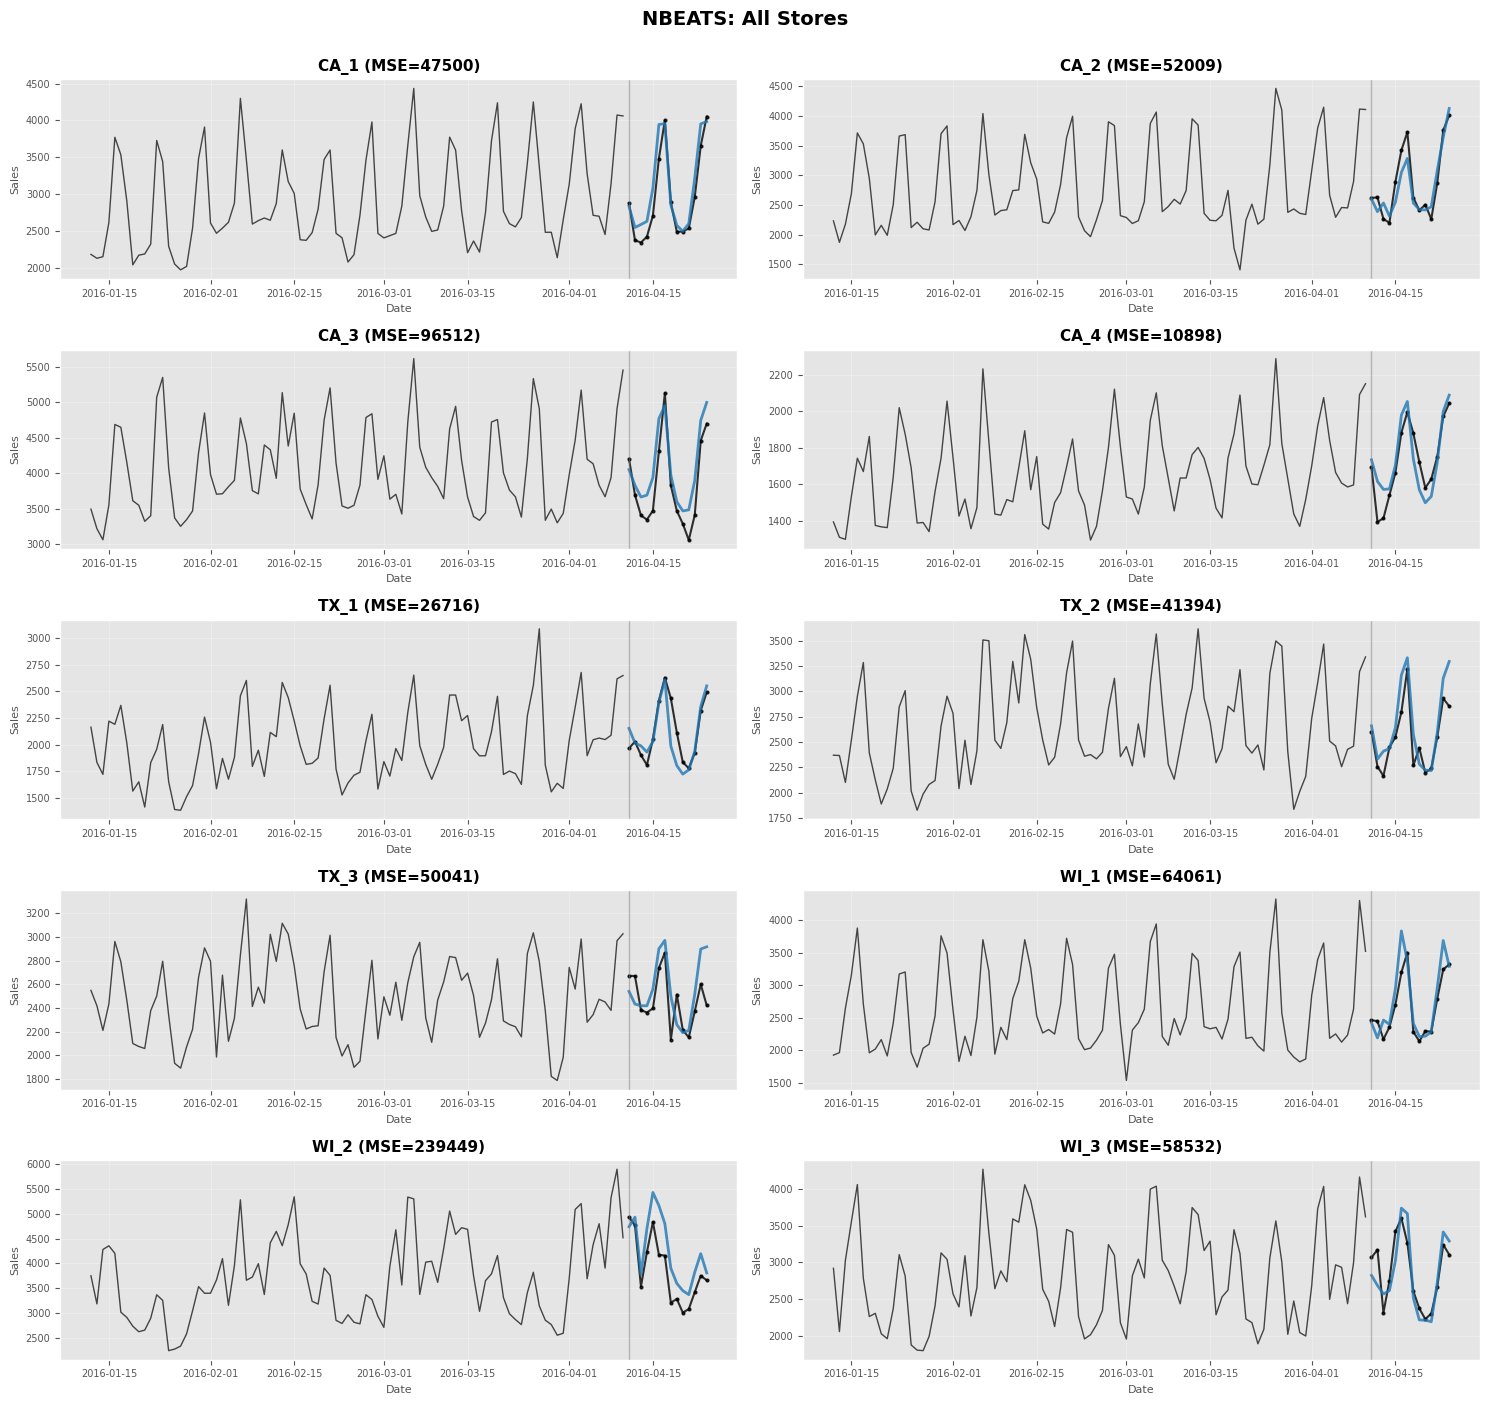


Average MSE across all stores: 68711.22


In [13]:
# Visualize NBEATS forecasts for all stores
fig, axes = plt.subplots(5, 2, figsize=(15, 14))
axes = axes.flatten()

# Merge forecasts with actual test values
forecasts_nbeats_merged = forecasts_nbeats.reset_index().merge(
    df_test_nf[["unique_id", "ds", "y"]], on=["unique_id", "ds"]
)

mse_nbeats = {}

for idx, store in enumerate(stores):
    train_store = df_train_nf[df_train_nf["unique_id"] == store].sort_values("ds")
    test_store = df_test_nf[df_test_nf["unique_id"] == store].sort_values("ds")
    forecast_store = forecasts_nbeats_merged[
        forecasts_nbeats_merged["unique_id"] == store
    ].sort_values("ds")

    # Plot training data (last 90 days)
    train_context = train_store.tail(90)
    axes[idx].plot(
        train_context["ds"], train_context["y"], color="black", linewidth=1, alpha=0.7
    )

    # Plot actual test data
    axes[idx].plot(
        test_store["ds"],
        test_store["y"],
        color="black",
        linewidth=1.5,
        alpha=0.8,
        marker="o",
        markersize=2,
    )

    # Plot forecast
    axes[idx].plot(
        forecast_store["ds"],
        forecast_store["NBEATS"],
        color="#1f77b4",
        linewidth=2,
        linestyle="-",
        alpha=0.8,
    )

    # Mark split
    axes[idx].axvline(x=split_date, color="gray", linestyle="-", linewidth=1, alpha=0.5)

    # Calculate MSE
    mse = mean_squared_error(forecast_store["y"], forecast_store["NBEATS"])
    mse_nbeats[store] = mse

    axes[idx].set_title(f"{store} (MSE={mse:.0f})", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Date", fontsize=8)
    axes[idx].set_ylabel("Sales", fontsize=8)
    axes[idx].tick_params(labelsize=7)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle(
    "NBEATS: All Stores", fontsize=14, fontweight="bold", y=1.00
)
plt.tight_layout()
plt.show()

avg_mse_nbeats = np.mean(list(mse_nbeats.values()))
print(f"\nAverage MSE across all stores: {avg_mse_nbeats:.2f}")

## 6. Train NHITS with Default Parameters


In [10]:
# Train NHITS with simple parameters
print("Training NHITS...")

models_nhits = [
    NHITS(
        h=test_size,
        input_size=2 * test_size,
        max_steps=500,
        early_stop_patience_steps=3
    )
]

# Create NeuralForecast object
nf_nhits = NeuralForecast(models=models_nhits, freq="D")

# Fit model
nf_nhits.fit(df=df_train_nf, val_size=5*14)

# Generate forecasts
forecasts_nhits = nf_nhits.predict()

print("\n✅ NHITS trained and forecasted!")
print(f"Forecast shape: {forecasts_nhits.shape}")
forecasts_nhits.head()

Seed set to 1


Training NHITS...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.4 M  | train
-------------------------------------------------------
2.4 M     Trainable params
0         Non-trainable params
2.4 M     Total params
9.798     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Epoch 499: 100%|██████████| 1/1 [00:00<00:00,  3.46it/s, v_num=12, train_loss_step=226.0, train_loss_epoch=226.0, valid_loss=237.0]

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 499: 100%|██████████| 1/1 [00:00<00:00,  3.38it/s, v_num=12, train_loss_step=226.0, train_loss_epoch=226.0, valid_loss=237.0]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 66.66it/s]

✅ NHITS trained and forecasted!
Forecast shape: (140, 3)


,unique_id,ds,NHITS
0,CA_1,2016-04-11,2817.155518
1,CA_1,2016-04-12,2593.997803
2,CA_1,2016-04-13,2591.920898
3,CA_1,2016-04-14,2552.424805
4,CA_1,2016-04-15,3034.882568


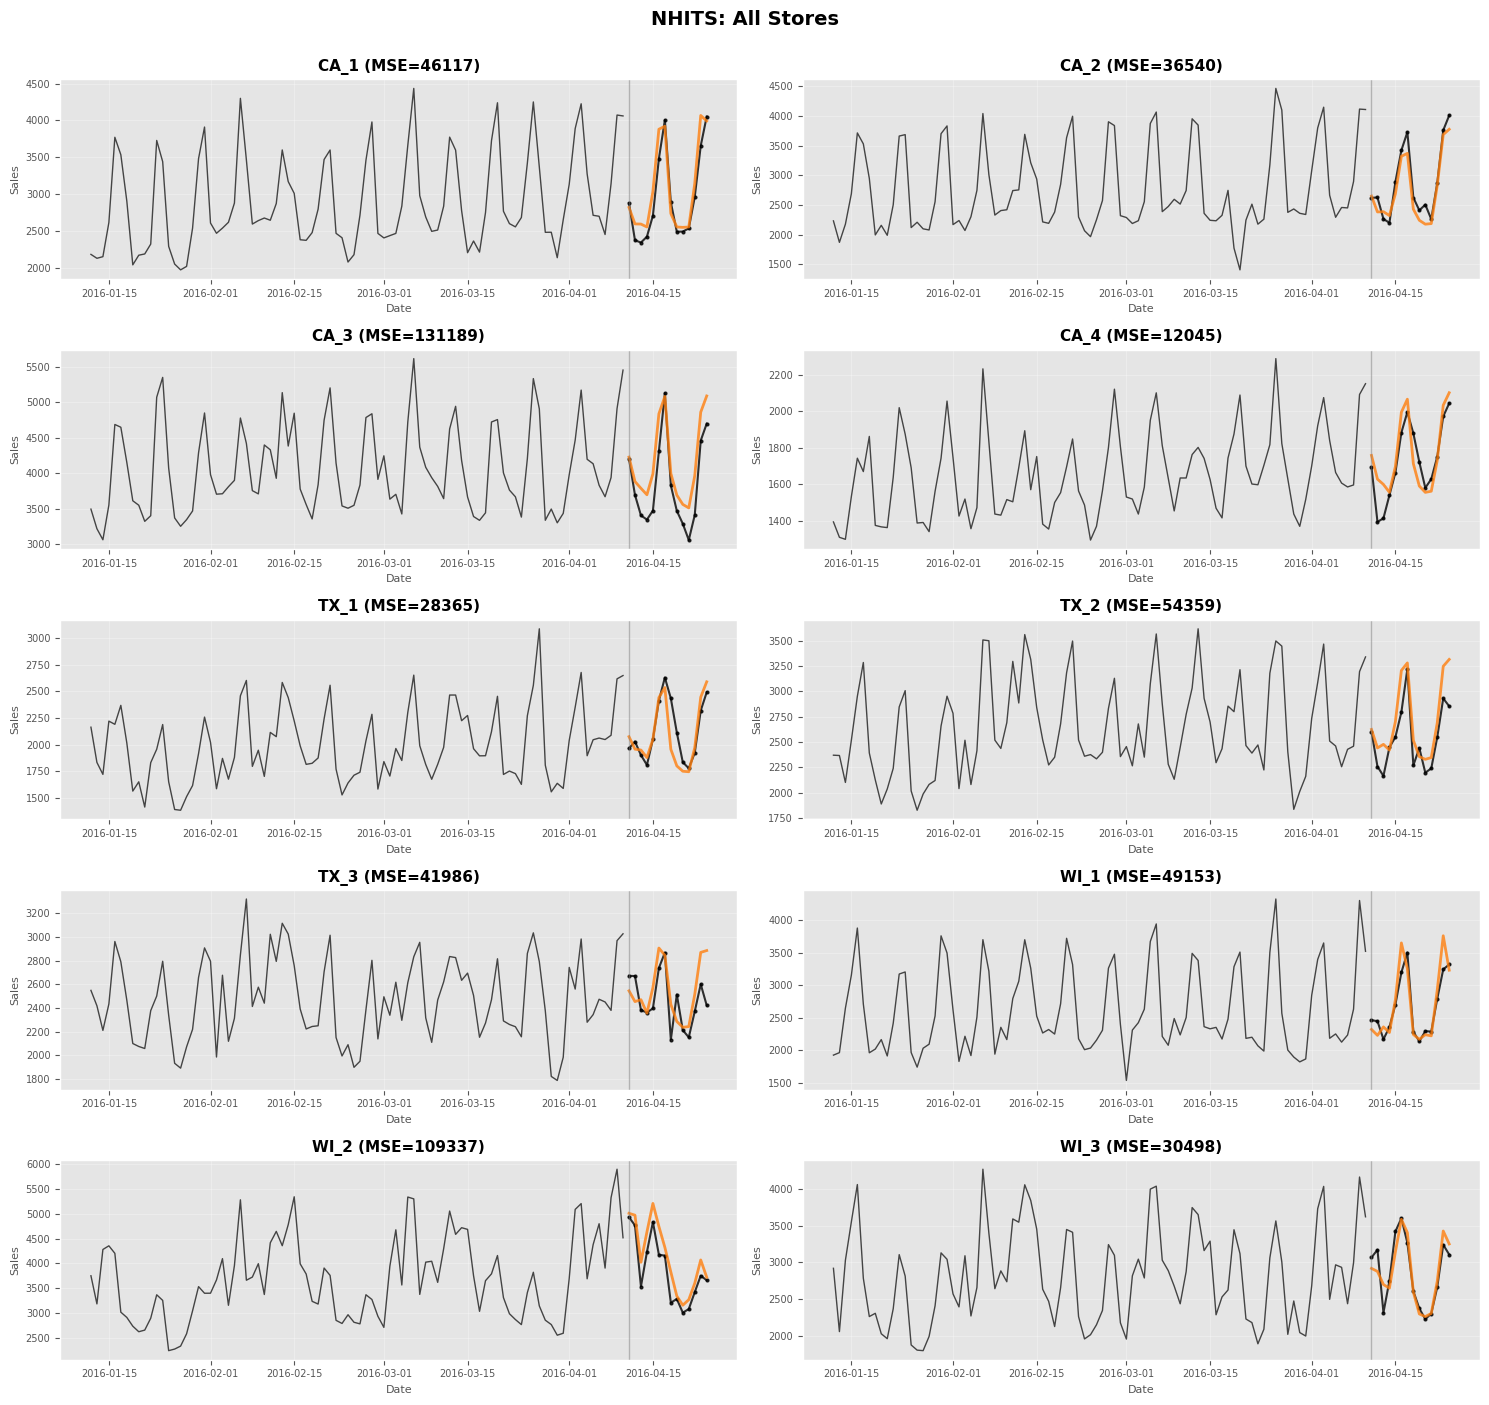


Average MSE across all stores: 53958.76


In [14]:
# Visualize NHITS forecasts for all stores
fig, axes = plt.subplots(5, 2, figsize=(15, 14))
axes = axes.flatten()

# Merge forecasts with actual test values
forecasts_nhits_merged = forecasts_nhits.reset_index().merge(
    df_test_nf[["unique_id", "ds", "y"]], on=["unique_id", "ds"]
)

mse_nhits = {}

for idx, store in enumerate(stores):
    train_store = df_train_nf[df_train_nf["unique_id"] == store].sort_values("ds")
    test_store = df_test_nf[df_test_nf["unique_id"] == store].sort_values("ds")
    forecast_store = forecasts_nhits_merged[
        forecasts_nhits_merged["unique_id"] == store
    ].sort_values("ds")

    # Plot training data (last 90 days)
    train_context = train_store.tail(90)
    axes[idx].plot(
        train_context["ds"], train_context["y"], color="black", linewidth=1, alpha=0.7
    )

    # Plot actual test data
    axes[idx].plot(
        test_store["ds"],
        test_store["y"],
        color="black",
        linewidth=1.5,
        alpha=0.8,
        marker="o",
        markersize=2,
    )

    # Plot forecast
    axes[idx].plot(
        forecast_store["ds"],
        forecast_store["NHITS"],
        color="#ff7f0e",
        linewidth=2,
        linestyle="-",
        alpha=0.8,
    )

    # Mark split
    axes[idx].axvline(x=split_date, color="gray", linestyle="-", linewidth=1, alpha=0.5)

    # Calculate MSE
    mse = mean_squared_error(forecast_store["y"], forecast_store["NHITS"])
    mse_nhits[store] = mse

    axes[idx].set_title(f"{store} (MSE={mse:.0f})", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Date", fontsize=8)
    axes[idx].set_ylabel("Sales", fontsize=8)
    axes[idx].tick_params(labelsize=7)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle(
    "NHITS: All Stores", fontsize=14, fontweight="bold", y=1.00
)
plt.tight_layout()
plt.show()

avg_mse_nhits = np.mean(list(mse_nhits.values()))
print(f"\nAverage MSE across all stores: {avg_mse_nhits:.2f}")

## 7. Compare Basic Models

Let's compare NBEATS and NHITS performance across all stores.

MSE Comparison: NBEATS vs NHITS (Default Parameters)
Store      NBEATS               NHITS               
------------------------------------------------------------
CA_1       47499.99             46116.68            
CA_2       52009.28             36539.89            
CA_3       96512.23             131189.33           
CA_4       10897.90             12044.91            
TX_1       26716.17             28364.68            
TX_2       41394.10             54358.96            
TX_3       50040.69             41985.88            
WI_1       64060.93             49152.57            
WI_2       239449.05            109336.62           
WI_3       58531.91             30498.09            
------------------------------------------------------------
Average    68711.22             53958.76            


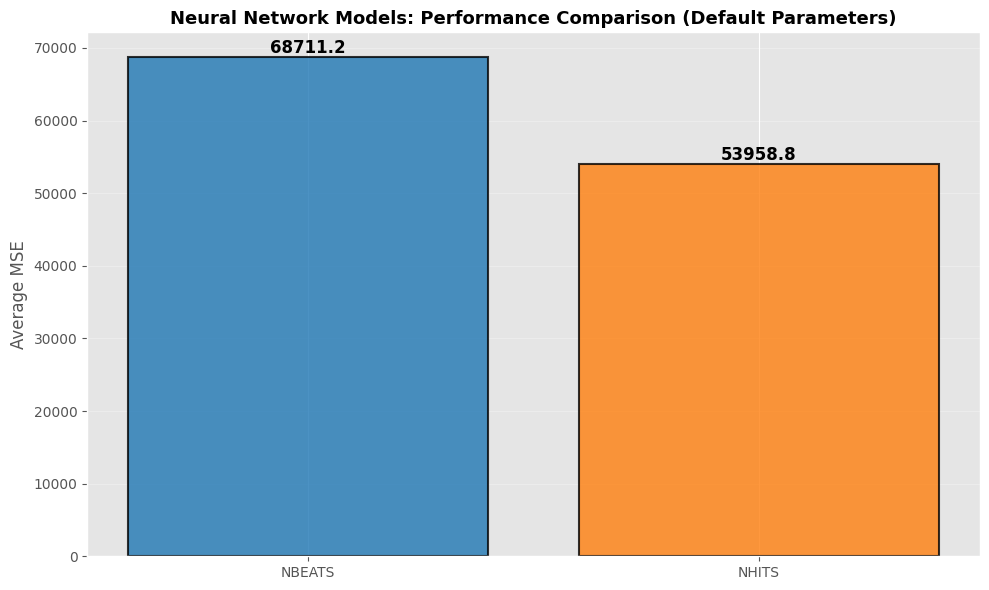


💡 Both models capture patterns, but can we improve with automatic tuning?


In [15]:
# Print MSE comparison table
print("MSE Comparison: NBEATS vs NHITS (Default Parameters)")
print("=" * 60)
print(f"{'Store':<10} {'NBEATS':<20} {'NHITS':<20}")
print("-" * 60)
for store in stores:
    print(f"{store:<10} {mse_nbeats[store]:<20.2f} {mse_nhits[store]:<20.2f}")

# Average across stores
print("-" * 60)
print(f"{'Average':<10} {avg_mse_nbeats:<20.2f} {avg_mse_nhits:<20.2f}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))

model_names = ["NBEATS", "NHITS"]
avg_mses = [avg_mse_nbeats, avg_mse_nhits]
colors = ["#1f77b4", "#ff7f0e"]

bars = ax.bar(model_names, avg_mses, color=colors, alpha=0.8, edgecolor="black", linewidth=1.5)

# Add value labels
for bar, mse in zip(bars, avg_mses):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{mse:.1f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

ax.set_ylabel("Average MSE", fontsize=12)
ax.set_title("Neural Network Models: Performance Comparison (Default Parameters)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("\n💡 Both models capture patterns, but can we improve with automatic tuning?")

## 8. Automatic Hyperparameter Tuning with Auto Models

NeuralForecast provides **Auto- models** that automatically search for optimal hyperparameters!

### What are Auto Models?

Auto models use **Ray** or **Optuna** to automatically find the best hyperparameters:
- **AutoNBEATS**: Automatic hyperparameter optimization for NBEATS
- **AutoNHITS**: Automatic hyperparameter optimization for NHITS

### Key Parameters They Tune:
- **`input_size`**: How many historical steps to use (context window)
- **`learning_rate`**: Step size for gradient descent
- **`batch_size`**: Number of samples per training iteration
- **`max_steps`**: Number of training iterations
- **Architecture-specific**: stack types, hidden sizes, etc.

### How Auto Models Work:
1. You define a **search space** (or use defaults)
2. Specify **number of trials** (`num_samples`)
3. Auto model tries different configurations
4. Returns the **best model** based on validation loss

Let's use Auto models with a simple configuration!

## 9. AutoNBEATS: Automatic Hyperparameter Tuning

We'll use AutoNBEATS to automatically find the best hyperparameters.

**Key parameters**:
- `h`: Forecast horizon (14 days)
- `num_samples`: Number of hyperparameter configurations to try (keep low for speed)
- `config`: Custom search space (None = use defaults)

In [ ]:
# Train AutoNBEATS with automatic hyperparameter tuning
print("Training AutoNBEATS with automatic hyperparameter tuning...")
print("This will try multiple configurations and select the best one.\n")

# Initialize AutoNBEATS
# num_samples = number of hyperparameter configurations to try (3-5 for quick demo)
# config = search space (None uses sensible defaults)
nbeats_config = AutoNBEATS.get_default_config(h = 14, backend = 'ray')                    # Extract the default hyperparameter settings

models_auto_nbeats = [
    AutoNBEATS(
        h=test_size,
        num_samples=3,  # Try 3 different configurations (keep low for speed)
        config=nbeats_config      # Use default search space
    )
]

# Create NeuralForecast object
nf_auto_nbeats = NeuralForecast(models=models_auto_nbeats, freq="D")

# Fit model (this will automatically tune hyperparameters)
nf_auto_nbeats.fit(df=df_train_nf)

# Generate forecasts
forecasts_auto_nbeats = nf_auto_nbeats.predict()

print("\n✅ AutoNBEATS trained and forecasted!")
print(f"Forecast shape: {forecasts_auto_nbeats.shape}")
forecasts_auto_nbeats.head()

(_train_tune pid=19556) c:\Users\u0153325\OneDrive - Hogeschool VIVES\Documenten\VIS\Cloud-for-AI\.venv\lib\site-packages\ray\tune\integration\pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=19556) Seed set to 3
(_train_tune pid=19556) GPU available: False, used: False
(_train_tune pid=19556) TPU available: False, using: 0 TPU cores
(_train_tune pid=19556) HPU available: False, using: 0 HPUs
(_train_tune pid=19556) 
(_train_tune pid=19556)   | Name         | Type          | Params | Mode 
(_train_tune pid=19556) -------------------------------------------------------
(_train_tune pid=19556) 0 | loss         | MAE           | 0      | train
(_train_tune pid=19556) 1 | padder_train | ConstantPad1d | 0      | train
(_train_tune pid=19556) 2 | scaler       | TemporalNorm  | 0      | train
(_train_tune pid=19556) 3 | blocks       | ModuleLi

Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 14.41it/s, v_num=0, train_loss_step=0.468, train_loss_epoch=0.488]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]
(_train_tune pid=19556) 
Validation DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 166.67it/s]
(_train_tune pid=19556) 
Epoch 199: 100%|██████████| 1/1 [00:00<00:00,  8.15it/s, v_num=0, train_loss_step=0.353, train_loss_epoch=0.361, valid_loss=527.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 12.39it/s, v_num=0, train_loss_step=0.301, train_loss_epoch=0.304, valid_loss=546.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 399: 100%|██████████| 1/1 [00:00<00:00, 11.11it/s, v_num=0, train_loss_step=0.268, train_loss_epoch=0.259, v

(_train_tune pid=19556) `Trainer.fit` stopped: `max_steps=500` reached.


Epoch 499: 100%|██████████| 1/1 [00:00<00:00, 10.49it/s, v_num=0, train_loss_step=0.240, train_loss_epoch=0.239, valid_loss=564.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 499: 100%|██████████| 1/1 [00:00<00:00,  8.50it/s, v_num=0, train_loss_step=0.240, train_loss_epoch=0.240, valid_loss=573.0]


(_train_tune pid=3004) c:\Users\u0153325\OneDrive - Hogeschool VIVES\Documenten\VIS\Cloud-for-AI\.venv\lib\site-packages\ray\tune\integration\pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=3004) Seed set to 3
(_train_tune pid=3004) GPU available: False, used: False
(_train_tune pid=3004) TPU available: False, using: 0 TPU cores
(_train_tune pid=3004) HPU available: False, using: 0 HPUs
(_train_tune pid=3004) 
(_train_tune pid=3004)   | Name         | Type          | Params | Mode 
(_train_tune pid=3004) -------------------------------------------------------
(_train_tune pid=3004) 0 | loss         | MAE           | 0      | train
(_train_tune pid=3004) 1 | padder_train | ConstantPad1d | 0      | train
(_train_tune pid=3004) 2 | scaler       | TemporalNorm  | 0      | train
(_train_tune pid=3004) 3 | blocks       | ModuleList    | 2.5 

...

(_train_tune pid=2368) `Trainer.fit` stopped: `max_steps=1000.0` reached.
(_train_tune pid=25644) c:\Users\u0153325\OneDrive - Hogeschool VIVES\Documenten\VIS\Cloud-for-AI\.venv\lib\site-packages\ray\tune\integration\pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=25644) Seed set to 3
(_train_tune pid=25644) GPU available: False, used: False
(_train_tune pid=25644) TPU available: False, using: 0 TPU cores
(_train_tune pid=25644) HPU available: False, using: 0 HPUs
(_train_tune pid=25644) 
(_train_tune pid=25644)   | Name         | Type          | Params | Mode 
(_train_tune pid=25644) -------------------------------------------------------
(_train_tune pid=25644) 0 | loss         | MAE           | 0      | train
(_train_tune pid=25644) 1 | padder_train | ConstantPad1d | 0      | train
(_train_tune pid=25644) 2 | scaler       | Temporal

Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 22.22it/s, v_num=0, train_loss_step=5.44e+5, train_loss_epoch=3.93e+5]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 166.69it/s]
(_train_tune pid=25644) 
Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 24.23it/s, v_num=0, train_loss_step=6.06e+4, train_loss_epoch=6.32e+4, valid_loss=2.15e+8]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 21.37it/s, v_num=0, train_loss_step=3.59e+4, train_loss_epoch=3.6e+4, valid_loss=5.23e+7] 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 399: 100%|██████████| 1/1 [00:00<00:00, 23.76it/s, v_num=0, train_loss_step=3.1e+4, train_loss_epoch=3.1e+4, valid_loss=3.21e+7]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 499:

(_train_tune pid=25644) `Trainer.fit` stopped: `max_steps=1000.0` reached.
(_train_tune pid=24596) c:\Users\u0153325\OneDrive - Hogeschool VIVES\Documenten\VIS\Cloud-for-AI\.venv\lib\site-packages\ray\tune\integration\pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=24596) Seed set to 14
(_train_tune pid=24596) GPU available: False, used: False
(_train_tune pid=24596) TPU available: False, using: 0 TPU cores
(_train_tune pid=24596) HPU available: False, using: 0 HPUs
(_train_tune pid=24596) 
(_train_tune pid=24596)   | Name         | Type          | Params | Mode 
(_train_tune pid=24596) -------------------------------------------------------
(_train_tune pid=24596) 0 | loss         | MAE           | 0      | train
(_train_tune pid=24596) 1 | padder_train | ConstantPad1d | 0      | train
(_train_tune pid=24596) 2 | scaler       | Tempor

Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 12.59it/s, v_num=0, train_loss_step=1.450, train_loss_epoch=1.400]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 111.20it/s]
(_train_tune pid=24596) 
Epoch 199: 100%|██████████| 1/1 [00:00<00:00,  8.82it/s, v_num=0, train_loss_step=1.280, train_loss_epoch=1.310, valid_loss=367.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]
(_train_tune pid=24596) 
Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 12.12it/s, v_num=0, train_loss_step=1.220, train_loss_epoch=1.170, valid_loss=362.0]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]
(_train_tune pid=24596) 
Epoch 399: 100%|██████████| 1/1 [00:00<00:00, 13.26it/s, v_num=0, train_loss_

(_train_tune pid=24596) `Trainer.fit` stopped: `max_steps=700.0` reached.


In [16]:
# Evaluate AutoNBEATS
forecasts_auto_nbeats_merged = forecasts_auto_nbeats.reset_index().merge(
    df_test_nf[["unique_id", "ds", "y"]], on=["unique_id", "ds"]
)

mse_auto_nbeats = {}

for store in stores:
    store_forecasts = forecasts_auto_nbeats_merged[
        forecasts_auto_nbeats_merged["unique_id"] == store
    ]
    mse = mean_squared_error(store_forecasts["y"], store_forecasts["AutoNBEATS"])
    mse_auto_nbeats[store] = mse

avg_mse_auto_nbeats = np.mean(list(mse_auto_nbeats.values()))

print("AutoNBEATS Results:")
print("=" * 60)
print(f"Average MSE: {avg_mse_auto_nbeats:.2f}")
print(f"\nComparison:")
print(f"  NBEATS (default):  {avg_mse_nbeats:.2f}")
print(f"  AutoNBEATS (tuned): {avg_mse_auto_nbeats:.2f}")

improvement = ((avg_mse_nbeats - avg_mse_auto_nbeats) / avg_mse_nbeats) * 100
print(f"  → Improvement: {improvement:.1f}%")

AutoNBEATS Results:
Average MSE: 61647.10

Comparison:
  NBEATS (default):  68711.22
  AutoNBEATS (tuned): 61647.10
  → Improvement: 10.3%


## 10. AutoNHITS: Automatic Hyperparameter Tuning

Now let's use AutoNHITS to automatically find the best hyperparameters for NHITS.

In [17]:
# Train AutoNHITS with automatic hyperparameter tuning
print("Training AutoNHITS with automatic hyperparameter tuning...")
print("This will try multiple configurations and select the best one.\n")


nhits_config = AutoNHITS.get_default_config(h = 14, backend = 'ray')                    # Extract the default hyperparameter settings


# Initialize AutoNHITS
models_auto_nhits = [
    AutoNHITS(
        h=test_size,
        num_samples=3,  # Try 3 different configurations
        config=nhits_config      # Use default search space
    )
]

# Create NeuralForecast object
nf_auto_nhits = NeuralForecast(models=models_auto_nhits, freq="D")

# Fit model (this will automatically tune hyperparameters)
nf_auto_nhits.fit(df=df_train_nf)

# Generate forecasts
forecasts_auto_nhits = nf_auto_nhits.predict()

print("\n✅ AutoNHITS trained and forecasted!")
print(f"Forecast shape: {forecasts_auto_nhits.shape}")
forecasts_auto_nhits.head()

2025-10-20 14:17:23,736	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'C:/Users/u0153325/ray_results/_train_tune_2025-10-20_14-14-03' in 0.0303s.
Seed set to 14
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | eval 
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.4 M  | train
-------------------------------------------------------
2.4 M     Trainable params
0         Non-trainable params
2.4 M     Total params
9.638     Total estimated model params size (MB)
33        Modules in train mode
1         Modules in eval mode


Epoch 699: 100%|██████████| 1/1 [00:00<00:00, 10.14it/s, v_num=14, train_loss_step=1.120, train_loss_epoch=1.120]

`Trainer.fit` stopped: `max_steps=700.0` reached.


Epoch 699: 100%|██████████| 1/1 [00:00<00:00,  9.73it/s, v_num=14, train_loss_step=1.120, train_loss_epoch=1.120]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 142.85it/s]

✅ AutoNHITS trained and forecasted!
Forecast shape: (140, 3)


,unique_id,ds,AutoNHITS
0,CA_1,2016-04-11,2833.392822
1,CA_1,2016-04-12,2645.168213
2,CA_1,2016-04-13,2582.711182
3,CA_1,2016-04-14,2641.958984
4,CA_1,2016-04-15,3037.559570


In [18]:
# Evaluate AutoNHITS
forecasts_auto_nhits_merged = forecasts_auto_nhits.reset_index().merge(
    df_test_nf[["unique_id", "ds", "y"]], on=["unique_id", "ds"]
)

mse_auto_nhits = {}

for store in stores:
    store_forecasts = forecasts_auto_nhits_merged[
        forecasts_auto_nhits_merged["unique_id"] == store
    ]
    mse = mean_squared_error(store_forecasts["y"], store_forecasts["AutoNHITS"])
    mse_auto_nhits[store] = mse

avg_mse_auto_nhits = np.mean(list(mse_auto_nhits.values()))

print("AutoNHITS Results:")
print("=" * 60)
print(f"Average MSE: {avg_mse_auto_nhits:.2f}")
print(f"\nComparison:")
print(f"  NHITS (default):  {avg_mse_nhits:.2f}")
print(f"  AutoNHITS (tuned): {avg_mse_auto_nhits:.2f}")

improvement = ((avg_mse_nhits - avg_mse_auto_nhits) / avg_mse_nhits) * 100
print(f"  → Improvement: {improvement:.1f}%")

AutoNHITS Results:
Average MSE: 107330.77

Comparison:
  NHITS (default):  53958.76
  AutoNHITS (tuned): 107330.77
  → Improvement: -98.9%


## 11. Compare All Models

Let's compare default models vs auto-tuned models.

MSE Comparison: Default vs Auto-Tuned Models
Store      NBEATS          AutoNBEATS      NHITS           AutoNHITS      
--------------------------------------------------------------------------------
CA_1       47499.99        32322.65        46116.68        39028.31       
CA_2       52009.28        68605.03        36539.89        65821.38       
CA_3       96512.23        70231.73        131189.33       151997.55      
CA_4       10897.90        9721.30         12044.91        15880.18       
TX_1       26716.17        33444.61        28364.68        28103.11       
TX_2       41394.10        32392.14        54358.96        33716.14       
TX_3       50040.69        36884.88        41985.88        39447.91       
WI_1       64060.93        52407.55        49152.57        30968.86       
WI_2       239449.05       225122.30       109336.62       561576.31      
WI_3       58531.91        55338.85        30498.09        106767.98      
-------------------------------------------------

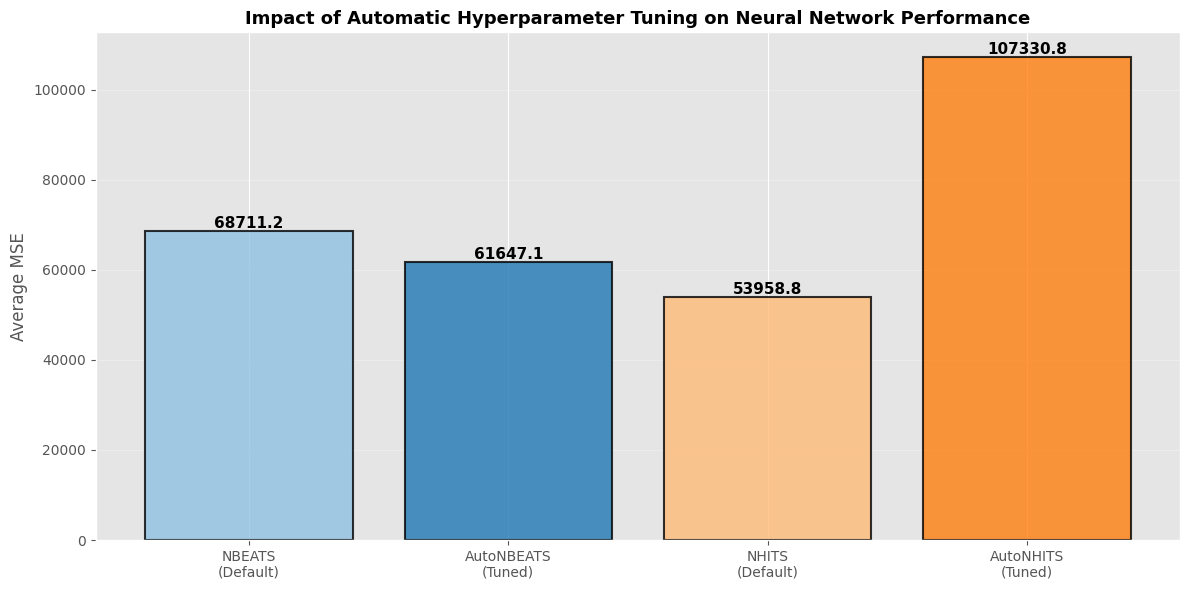


💡 Automatic Tuning Impact:
  NBEATS: 10.3% improvement
  NHITS: -98.9% improvement
  → Auto models automatically find better hyperparameters!


In [19]:
# Print comprehensive MSE comparison
print("MSE Comparison: Default vs Auto-Tuned Models")
print("=" * 80)
print(f"{'Store':<10} {'NBEATS':<15} {'AutoNBEATS':<15} {'NHITS':<15} {'AutoNHITS':<15}")
print("-" * 80)

for store in stores:
    print(
        f"{store:<10} {mse_nbeats[store]:<15.2f} {mse_auto_nbeats[store]:<15.2f} "
        f"{mse_nhits[store]:<15.2f} {mse_auto_nhits[store]:<15.2f}"
    )

# Average across stores
print("-" * 80)
print(
    f"{'Average':<10} {avg_mse_nbeats:<15.2f} {avg_mse_auto_nbeats:<15.2f} "
    f"{avg_mse_nhits:<15.2f} {avg_mse_auto_nhits:<15.2f}"
)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))

models = ["NBEATS\n(Default)", "AutoNBEATS\n(Tuned)", "NHITS\n(Default)", "AutoNHITS\n(Tuned)"]
avg_mses = [avg_mse_nbeats, avg_mse_auto_nbeats, avg_mse_nhits, avg_mse_auto_nhits]
colors = ["#8fc1e3", "#1f77b4", "#ffbb78", "#ff7f0e"]

bars = ax.bar(models, avg_mses, color=colors, alpha=0.8, edgecolor="black", linewidth=1.5)

# Add value labels
for bar, mse in zip(bars, avg_mses):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{mse:.1f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_ylabel("Average MSE", fontsize=12)
ax.set_title(
    "Impact of Automatic Hyperparameter Tuning on Neural Network Performance",
    fontsize=13,
    fontweight="bold",
)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Calculate improvements
nbeats_improvement = ((avg_mse_nbeats - avg_mse_auto_nbeats) / avg_mse_nbeats) * 100
nhits_improvement = ((avg_mse_nhits - avg_mse_auto_nhits) / avg_mse_nhits) * 100

print(f"\n💡 Automatic Tuning Impact:")
print(f"  NBEATS: {nbeats_improvement:.1f}% improvement")
print(f"  NHITS: {nhits_improvement:.1f}% improvement")
print("  → Auto models automatically find better hyperparameters!")

## 12. Visualize Best Model

Let's visualize the best performing model for all stores.

Best Model: NHITS
Average MSE: 53958.76



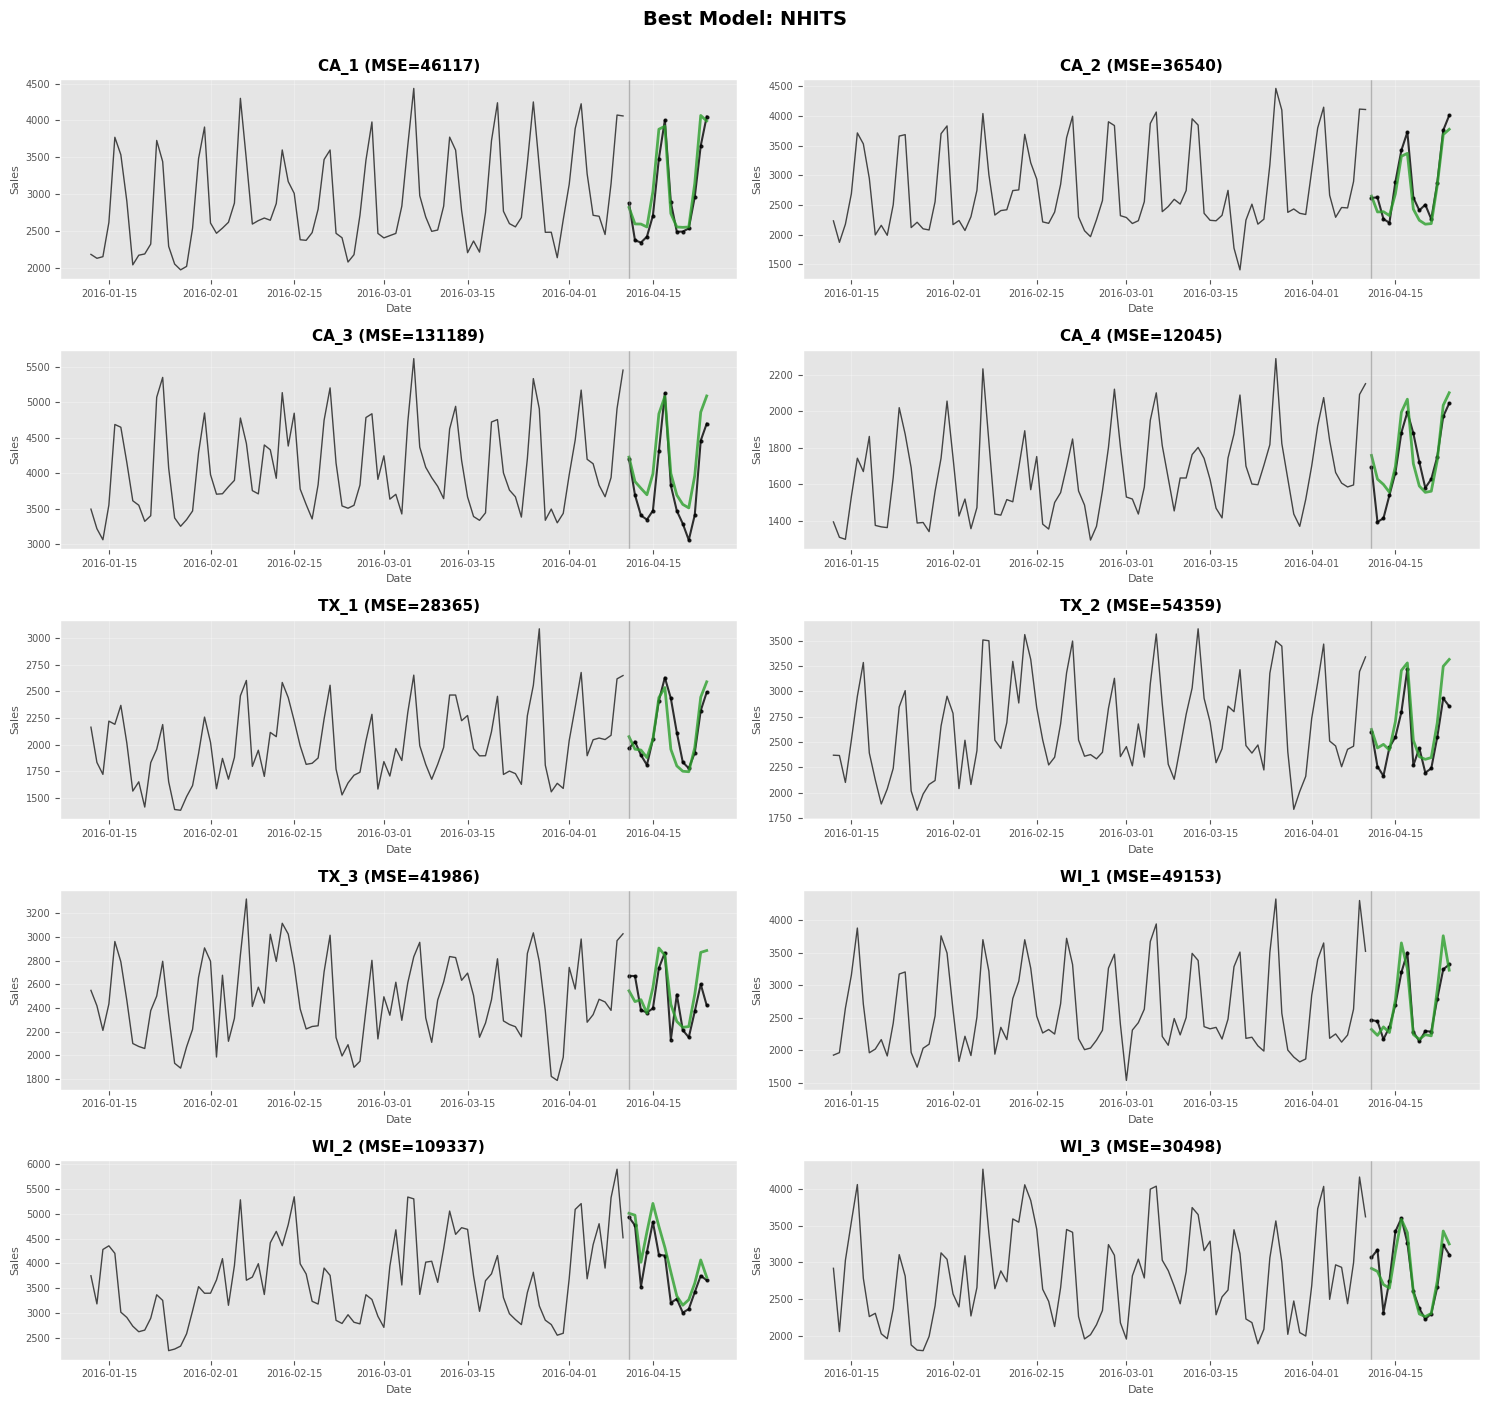

In [20]:
# Determine best model
all_avg_mses = {
    "NBEATS": avg_mse_nbeats,
    "AutoNBEATS": avg_mse_auto_nbeats,
    "NHITS": avg_mse_nhits,
    "AutoNHITS": avg_mse_auto_nhits
}

best_model_name = min(all_avg_mses, key=all_avg_mses.get)
best_avg_mse = all_avg_mses[best_model_name]

# Select best forecasts
if best_model_name == "NBEATS":
    best_forecasts = forecasts_nbeats_merged
    best_mse = mse_nbeats
elif best_model_name == "AutoNBEATS":
    best_forecasts = forecasts_auto_nbeats_merged
    best_mse = mse_auto_nbeats
elif best_model_name == "NHITS":
    best_forecasts = forecasts_nhits_merged
    best_mse = mse_nhits
else:
    best_forecasts = forecasts_auto_nhits_merged
    best_mse = mse_auto_nhits

print(f"Best Model: {best_model_name}")
print(f"Average MSE: {best_avg_mse:.2f}\n")

# Visualize best model for all stores
fig, axes = plt.subplots(5, 2, figsize=(15, 14))
axes = axes.flatten()

for idx, store in enumerate(stores):
    train_store = df_train_nf[df_train_nf["unique_id"] == store].sort_values("ds")
    test_store = df_test_nf[df_test_nf["unique_id"] == store].sort_values("ds")
    forecast_store = best_forecasts[
        best_forecasts["unique_id"] == store
    ].sort_values("ds")

    # Plot training data (last 90 days)
    train_context = train_store.tail(90)
    axes[idx].plot(
        train_context["ds"], train_context["y"], color="black", linewidth=1, alpha=0.7
    )

    # Plot actual test data
    axes[idx].plot(
        test_store["ds"],
        test_store["y"],
        color="black",
        linewidth=1.5,
        alpha=0.8,
        marker="o",
        markersize=2,
    )

    # Plot forecast
    color = "#2ca02c"
    axes[idx].plot(
        forecast_store["ds"],
        forecast_store[best_model_name],
        color=color,
        linewidth=2,
        linestyle="-",
        alpha=0.8,
    )

    # Mark split
    axes[idx].axvline(x=split_date, color="gray", linestyle="-", linewidth=1, alpha=0.5)

    mse = best_mse[store]
    axes[idx].set_title(f"{store} (MSE={mse:.0f})", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Date", fontsize=8)
    axes[idx].set_ylabel("Sales", fontsize=8)
    axes[idx].tick_params(labelsize=7)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle(
    f"Best Model: {best_model_name}", fontsize=14, fontweight="bold", y=1.00
)
plt.tight_layout()
plt.show()